#**Retail Store Sales Analysis and Prediction**

##**Introduction**
The Retail Store Sales Prediction project was developed to analyze customer transaction data and predict customer spending behavior using machine learning techniques. Retail businesses generate large amounts of transactional data every day, and analyzing this data can help organizations improve decision-making, sales strategies, inventory planning, and customer understanding.

This project focuses on the complete data science workflow, including data loading, data cleaning, exploratory data analysis (EDA), feature engineering, predictive modeling, model optimization, and visualization. The dataset contains retail transaction information such as product category, item type, quantity purchased, payment method, location, discount status, and total spending amount.

Machine learning models such as Linear Regression and Ridge Regression were used to predict the Total Spent value. Different visualizations and evaluation metrics were also applied to understand customer purchasing patterns and evaluate model performance.

Overall, this project demonstrates how data analytics and machine learning can be applied in the retail industry to support business intelligence and improve sales prediction accuracy.

##**Project Objectives**
The main objectives of this project are:
1.   To load and preprocess retail transaction
data for analysis and machine learning.
2.   To identify and handle missing values, inconsistent data, and duplicate records.
3. To perform Exploratory Data Analysis (EDA) using different visualizations to understand customer purchasing behavior and sales trends.
4. To create new features that improve the predictive performance of machine learning models.
5. To build predictive models that can estimate customer Total Spent values.
6. To evaluate machine learning models using regression metrics such as MAE, MSE, RMSE, and R-squared.
7. To optimize model performance using hyperparameter tuning and dimensionality reduction techniques.
8. To generate business insights that can help improve retail sales strategies and customer understanding.





##**Problem Statement**

Retail businesses generate large amounts of transaction data every day, but it is difficult to accurately predict customer spending behavior and sales patterns. Without proper analysis, businesses may face challenges in inventory management, sales forecasting, and understanding customer purchasing trends.

This project aims to analyze retail transaction data and use machine learning techniques to predict customer Total Spent values. The project also focuses on identifying important sales trends and customer behavior patterns that can support better business decision-making.

##Import Libraries and Dataset Loading





In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.linear_model import Ridge
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


# Make plots look clean
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)


In [ ]:
# Load the dataset
df = pd.read_csv('https://raw.githubusercontent.com/maybraniswe/Retail-Store-Sales-Analysis-and-Prediction/refs/heads/main/retail_store_sales.csv')

# Display first 5 rows
df.head()


,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,NaN
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False


Observation:

The dataset is successfully loaded into a pandas DataFrame.
It contains retail transaction information such as customer, category, item, price, quantity, payment method, and transaction date.

In [ ]:
# Check dataset size
df.shape

(12575, 11)

Observation:

The dataset contains 12,575 rows and 11 columns.
Each row represents one retail transaction record.

##Initial Data Inspection

In [ ]:
# Display first 5 rows
df.head()

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,NaN
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False


Observation:

The first few records show transaction details including Transaction ID, Customer ID, Category, Item, Price Per Unit, Quantity, Total Spent, Payment Method, Location, Transaction Date, and Discount Applied.

In [ ]:
# Display statistical summary for numerical columns
df.describe().round(2)

,Price Per Unit,Quantity,Total Spent
count,11966.00,11971.00,11971.00
mean,23.37,5.54,129.65
std,10.74,2.86,94.75
min,5.00,1.00,5.00
25%,14.00,3.00,51.00
50%,23.00,6.00,108.50
75%,33.50,8.00,192.00
max,41.00,10.00,410.00


Observation:

Price Per Unit ranges from 5.00 to 41.00.
Quantity ranges from 1 to 10.
Total Spent ranges from 5.00 to 410.00.
This shows that the numerical values are within a reasonable range.

In [ ]:
# Display full data information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    12575 non-null  object 
 1   Customer ID       12575 non-null  object 
 2   Category          12575 non-null  object 
 3   Item              11362 non-null  object 
 4   Price Per Unit    11966 non-null  float64
 5   Quantity          11971 non-null  float64
 6   Total Spent       11971 non-null  float64
 7   Payment Method    12575 non-null  object 
 8   Location          12575 non-null  object 
 9   Transaction Date  12575 non-null  object 
 10  Discount Applied  8376 non-null   object 
dtypes: float64(3), object(8)
memory usage: 1.1+ MB


Observation:

The dataset has both object and numeric data types.
Transaction Date is currently stored as object, so it needs to be converted to datetime.
Discount Applied is also stored as object and should be converted to boolean/category.

In [ ]:
# Check missing values
df.isnull().sum()

,0
Transaction ID,0
Customer ID,0
Category,0
Item,1213
Price Per Unit,609
Quantity,604
Total Spent,604
Payment Method,0
Location,0
Transaction Date,0


Observation:

Missing values are found in Item, Price Per Unit, Quantity, Total Spent, and Discount Applied.
These missing values need to be handled before analysis and modeling.

In [ ]:
# Check duplicate rows
df.duplicated().sum()

np.int64(0)

Observation:

This checks whether the dataset contains fully duplicate transaction rows.
Duplicate rows should be removed if found.

##Data Cleaning


In [ ]:
# Create a copy of the original dataset
clean_df = df.copy()

Observation:

A copy is created so the original dataset remains unchanged.
This is a good practice before performing data cleaning.

In [ ]:
# Remove duplicate rows
duplicate_count = clean_df.duplicated().sum()
print("Duplicate rows before cleaning:", duplicate_count)

clean_df = clean_df.drop_duplicates()

print("Duplicate rows after cleaning:", clean_df.duplicated().sum())

Duplicate rows before cleaning: 0
Duplicate rows after cleaning: 0


Observation:

Fully duplicate rows are checked and removed.
This helps avoid repeated records affecting the analysis.

In [ ]:
# Convert Transaction Date to datetime
clean_df["Transaction Date"] = pd.to_datetime(clean_df["Transaction Date"], errors="coerce")

clean_df["Transaction Date"].dtype

dtype('<M8[ns]')

Observation:

Transaction Date is converted from object to datetime format.
This allows future analysis by year, month, or day.

In [ ]:
# Standardize categorical text columns
categorical_cols = ["Transaction ID", "Customer ID", "Category", "Item",
                    "Payment Method", "Location", "Discount Applied"]

for col in categorical_cols:
    clean_df[col] = clean_df[col].astype(str).str.strip()

# Replace string 'nan' back to real missing values
clean_df = clean_df.replace("nan", np.nan)


Observation:

Extra spaces are removed from categorical columns.
This helps avoid inconsistent values such as 'Cash ' and 'Cash' being treated as different categories.

In [ ]:
# Handle all missing values

# Create reference table
item_price_table = clean_df[["Item", "Price Per Unit"]].dropna().drop_duplicates()

# Fill Item using Price Per Unit
price_to_item = item_price_table.drop_duplicates("Price Per Unit") \
                                .set_index("Price Per Unit")["Item"]

clean_df["Item"] = clean_df["Item"].fillna(
    clean_df["Price Per Unit"].map(price_to_item)
)

# Fill Price Per Unit using Item
item_to_price = item_price_table.drop_duplicates("Item") \
                                .set_index("Item")["Price Per Unit"]

clean_df["Price Per Unit"] = clean_df["Price Per Unit"].fillna(
    clean_df["Item"].map(item_to_price)
)

# Fill Quantity using median
clean_df["Quantity"] = clean_df["Quantity"].fillna(
    clean_df["Quantity"].median()
)

# Recalculate Total Spent
clean_df["Total Spent"] = clean_df["Price Per Unit"] * clean_df["Quantity"]

# Fill Discount Applied
clean_df["Discount Applied"] = clean_df["Discount Applied"].fillna(False)
clean_df["Discount Applied"] = clean_df["Discount Applied"].astype(bool)

Observation:

Missing values were handled using different strategies based on the column type.

Item and Price Per Unit were filled using their relationship.

Quantity was filled using the median value.

Total Spent was recalculated to maintain accuracy.

Discount Applied missing values were filled as False.

In [ ]:
# Check missing values after cleaning
clean_df.isnull().sum()

,0
Transaction ID,0
Customer ID,0
Category,0
Item,609
Price Per Unit,609
Quantity,0
Total Spent,609
Payment Method,0
Location,0
Transaction Date,0


Observation:

This confirms whether all missing values have been handled.
The main columns should now show 0 missing values.

In [ ]:
# Check cleaned dataset information
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    12575 non-null  object        
 1   Customer ID       12575 non-null  object        
 2   Category          12575 non-null  object        
 3   Item              11966 non-null  object        
 4   Price Per Unit    11966 non-null  float64       
 5   Quantity          12575 non-null  float64       
 6   Total Spent       11966 non-null  float64       
 7   Payment Method    12575 non-null  object        
 8   Location          12575 non-null  object        
 9   Transaction Date  12575 non-null  datetime64[ns]
 10  Discount Applied  12575 non-null  bool          
dtypes: bool(1), datetime64[ns](1), float64(3), object(6)
memory usage: 994.8+ KB


Observation:

This shows the updated data types and non-null counts.
It helps confirm that the cleaning process was successful.

In [ ]:
# Display cleaned dataset preview
clean_df.head()

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,True
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,False
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,True


Observation:

The first five rows of the cleaned dataset are displayed.
The dataset is now ready for EDA and modeling.

In [ ]:
# Save cleaned dataset
clean_df.to_csv("cleaned_retail_store_sales.csv", index=False)

Observation:

The cleaned dataset is saved as a new CSV file.
This file can be used for the next project stages.

In [ ]:
# Final cleaning summary
print("Original dataset shape:", df.shape)
print("Cleaned dataset shape:", clean_df.shape)

print("\nMissing values after cleaning:")
print(clean_df.isnull().sum())

print("\nDuplicate rows after cleaning:")
print(clean_df.duplicated().sum())

print("\nCleaned data types:")
print(clean_df.dtypes)

Original dataset shape: (12575, 11)
Cleaned dataset shape: (12575, 11)

Missing values after cleaning:
Transaction ID        0
Customer ID           0
Category              0
Item                609
Price Per Unit      609
Quantity              0
Total Spent         609
Payment Method        0
Location              0
Transaction Date      0
Discount Applied      0
dtype: int64

Duplicate rows after cleaning:
0

Cleaned data types:
Transaction ID              object
Customer ID                 object
Category                    object
Item                        object
Price Per Unit             float64
Quantity                   float64
Total Spent                float64
Payment Method              object
Location                    object
Transaction Date    datetime64[ns]
Discount Applied              bool
dtype: object


Observation:

The final summary shows the cleaned dataset size, missing values, duplicate rows, and data types.
The dataset is cleaned and ready for EDA, feature engineering, and machine learning.

##Exploratory Data Analysis (EDA)

####Univariate Analysis

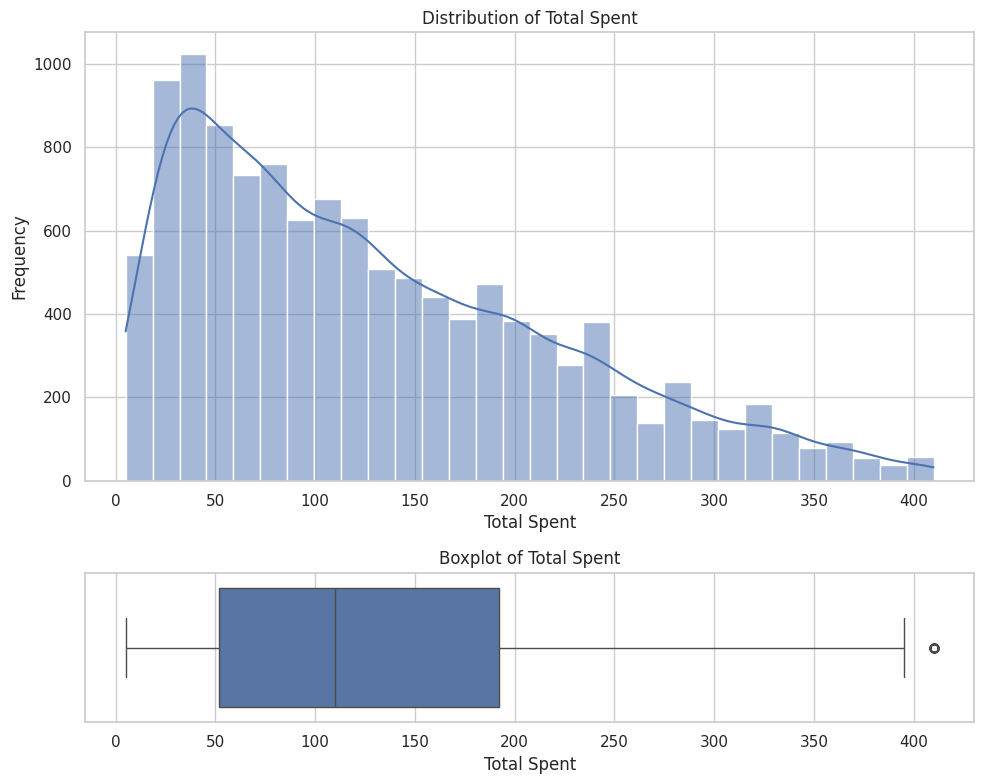

In [ ]:
# Histogram with KDE and Boxplot for Total Spent

fig, axes = plt.subplots(2, 1, figsize=(10, 8), gridspec_kw={"height_ratios": [3, 1]})

sns.histplot(clean_df["Total Spent"], kde=True, bins=30, ax=axes[0])
axes[0].set_title("Distribution of Total Spent")
axes[0].set_xlabel("Total Spent")
axes[0].set_ylabel("Frequency")

sns.boxplot(x=clean_df["Total Spent"], ax=axes[1])
axes[1].set_title("Boxplot of Total Spent")
axes[1].set_xlabel("Total Spent")

plt.tight_layout()
plt.show()


Observation:

The histogram shows how customer spending is distributed.
The KDE line helps show the overall spending pattern.
The boxplot shows the spread of Total Spent and helps identify possible outliers.

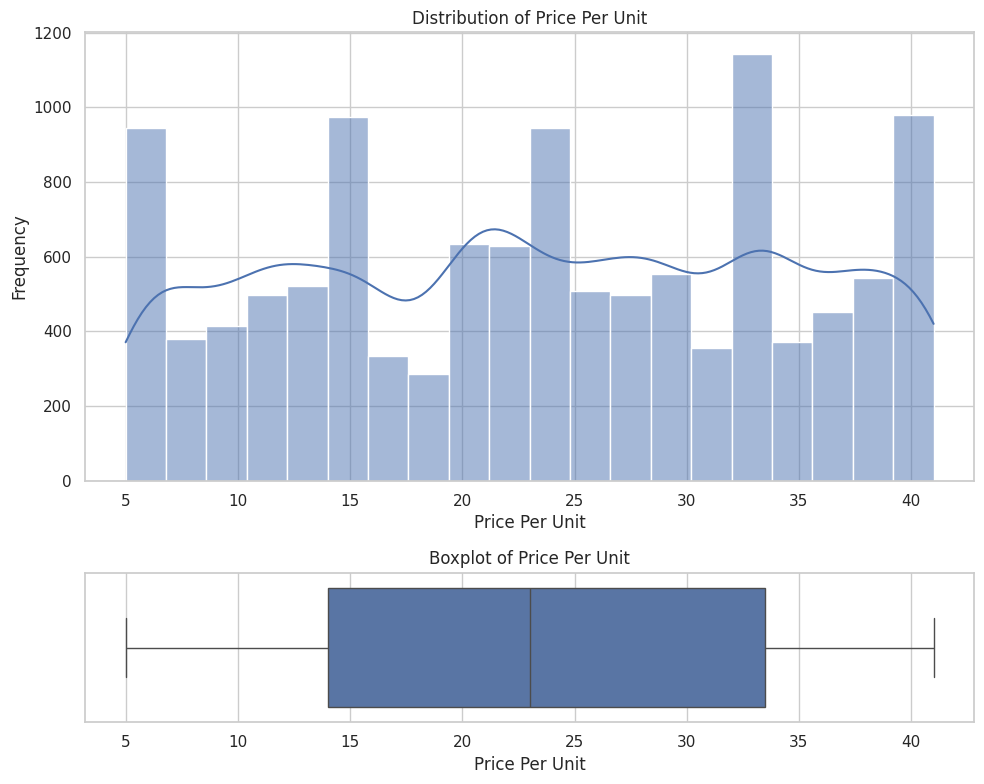

In [ ]:
# Histogram with KDE and Boxplot for Price Per Unit

fig, axes = plt.subplots(2, 1, figsize=(10, 8), gridspec_kw={"height_ratios": [3, 1]})

sns.histplot(clean_df["Price Per Unit"], kde=True, bins=20, ax=axes[0])
axes[0].set_title("Distribution of Price Per Unit")
axes[0].set_xlabel("Price Per Unit")
axes[0].set_ylabel("Frequency")

sns.boxplot(x=clean_df["Price Per Unit"], ax=axes[1])
axes[1].set_title("Boxplot of Price Per Unit")
axes[1].set_xlabel("Price Per Unit")

plt.tight_layout()
plt.show()

Observation:

This plot shows the distribution of item prices.
The boxplot helps identify whether some items have much higher unit prices than others.

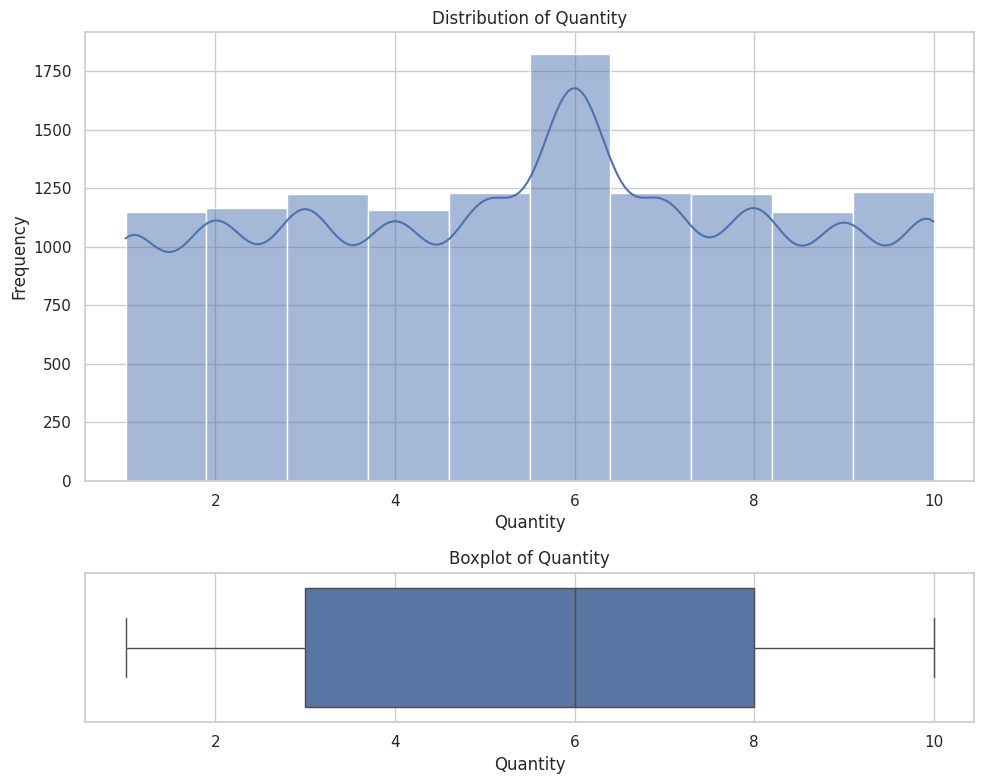

In [ ]:
# Histogram with KDE and Boxplot for Quantity

fig, axes = plt.subplots(2, 1, figsize=(10, 8), gridspec_kw={"height_ratios": [3, 1]})

sns.histplot(clean_df["Quantity"], kde=True, bins=10, ax=axes[0])
axes[0].set_title("Distribution of Quantity")
axes[0].set_xlabel("Quantity")
axes[0].set_ylabel("Frequency")

sns.boxplot(x=clean_df["Quantity"], ax=axes[1])
axes[1].set_title("Boxplot of Quantity")
axes[1].set_xlabel("Quantity")

plt.tight_layout()
plt.show()

Observation:

Most customers purchase small quantities of items.
The boxplot shows the spread of quantity values and possible outliers.

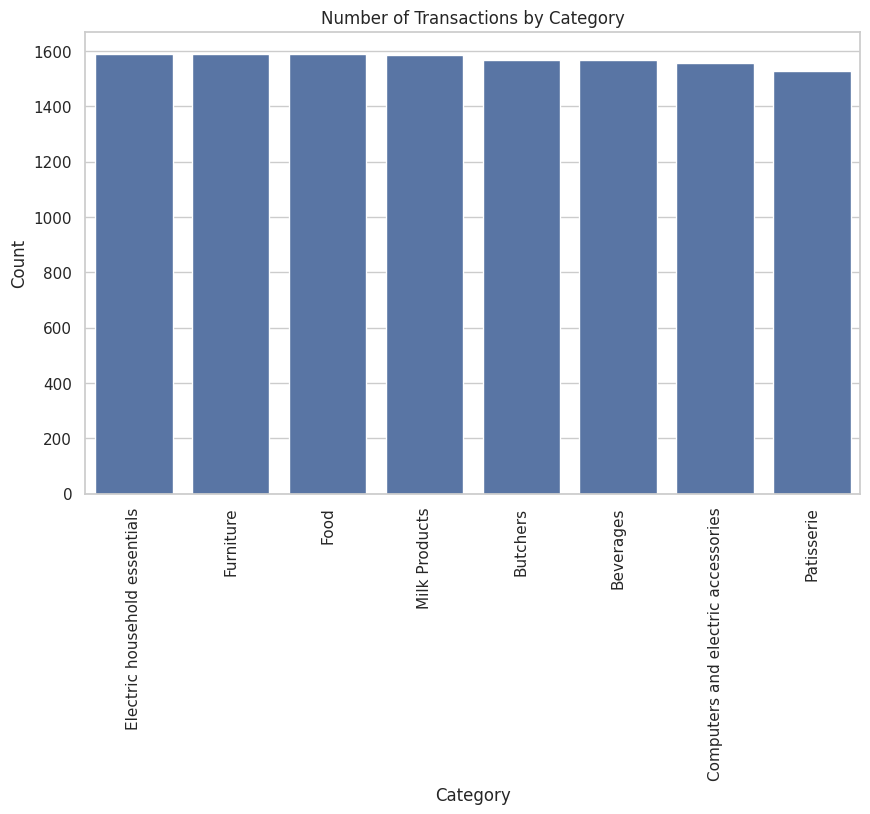

In [ ]:
# Countplot for Category

plt.figure(figsize=(10,6))

sns.countplot(data=clean_df, x="Category", order=clean_df["Category"].value_counts().index)

plt.title("Number of Transactions by Category")
plt.xlabel("Category")
plt.ylabel("Count")

plt.xticks(rotation=90)
plt.show()

Observation:

This bar chart shows the number of transactions in each product category.
Some categories are more popular and have higher transaction counts.

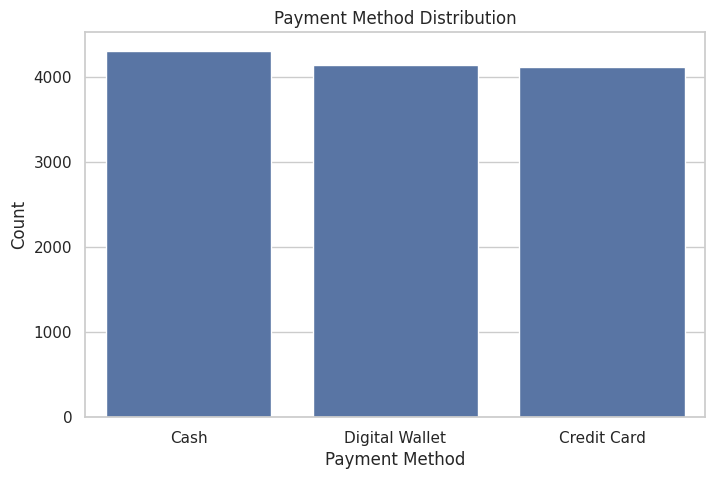

In [ ]:
# Countplot for Payment Method

plt.figure(figsize=(8,5))

sns.countplot(data=clean_df, x="Payment Method",
              order=clean_df["Payment Method"].value_counts().index)

plt.title("Payment Method Distribution")
plt.xlabel("Payment Method")
plt.ylabel("Count")

plt.show()

Observation:

This chart shows the most commonly used payment methods.
It helps identify customer payment preferences.

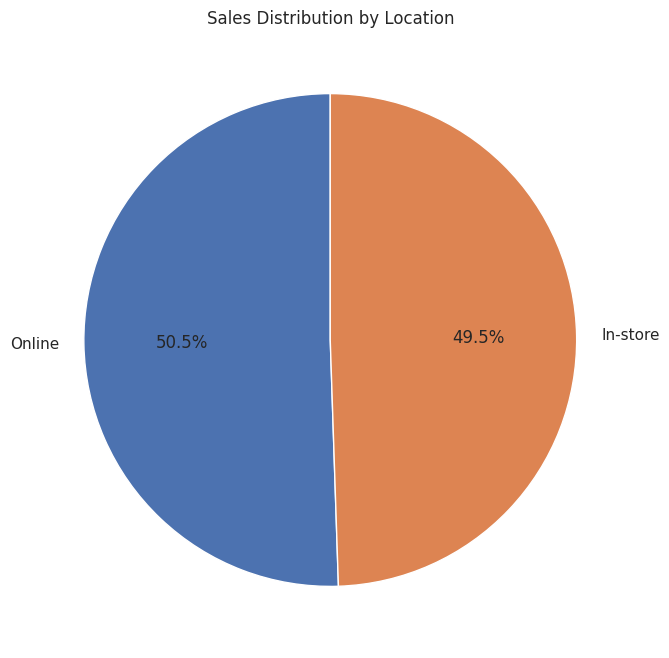

In [ ]:
# Pie chart for Location distribution

location_counts = clean_df["Location"].value_counts()

plt.figure(figsize=(8,8))

plt.pie(location_counts,
        labels=location_counts.index,
        autopct='%1.1f%%',
        startangle=90)

plt.title("Sales Distribution by Location")

plt.show()

Observation:

This pie chart shows the percentage of transactions by location.
Some locations contribute more sales than others.

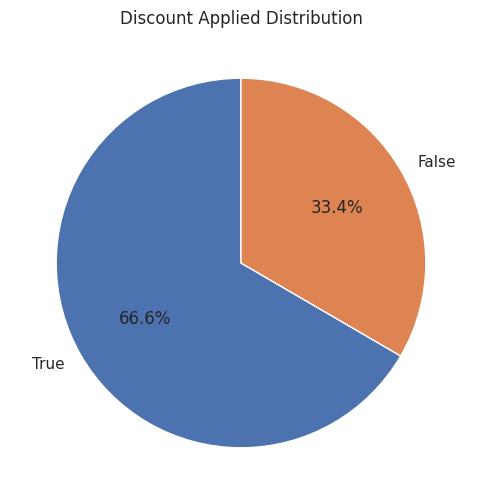

In [ ]:
# Pie chart for Discount Applied

discount_counts = clean_df["Discount Applied"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(discount_counts,
        labels=discount_counts.index,
        autopct='%1.1f%%',
        startangle=90)

plt.title("Discount Applied Distribution")

plt.show()

Observation:

This chart shows the proportion of transactions with and without discounts.
Most transactions may occur without discounts depending on customer behavior.

####Bivariate Analysis


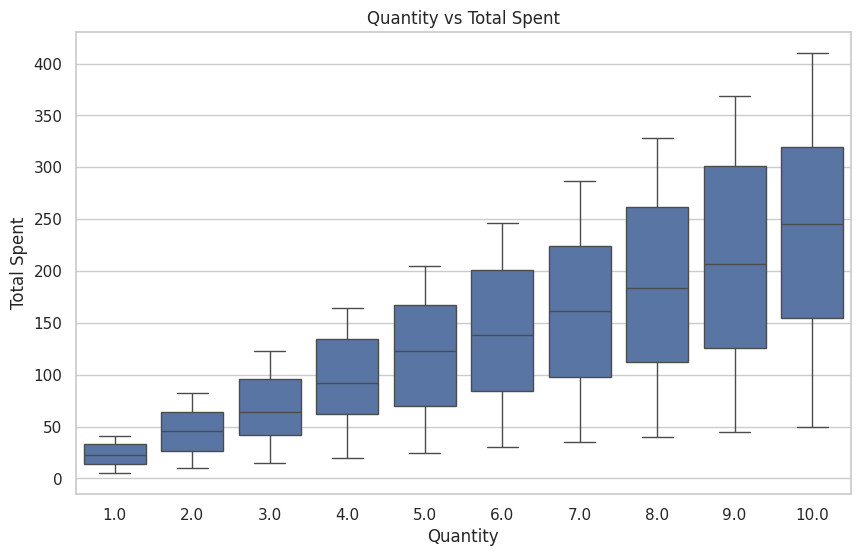

In [ ]:
# Boxplot: Quantity vs Total Spent

plt.figure(figsize=(10,6))

sns.boxplot(data=clean_df,
            x="Quantity",
            y="Total Spent")

plt.title("Quantity vs Total Spent")
plt.xlabel("Quantity")
plt.ylabel("Total Spent")

plt.show()

Observation:

This boxplot compares the distribution of Total Spent across different quantity levels.
Customers who purchase higher quantities generally have higher total spending.
The plot also helps identify spending variation and possible outliers for each quantity group.

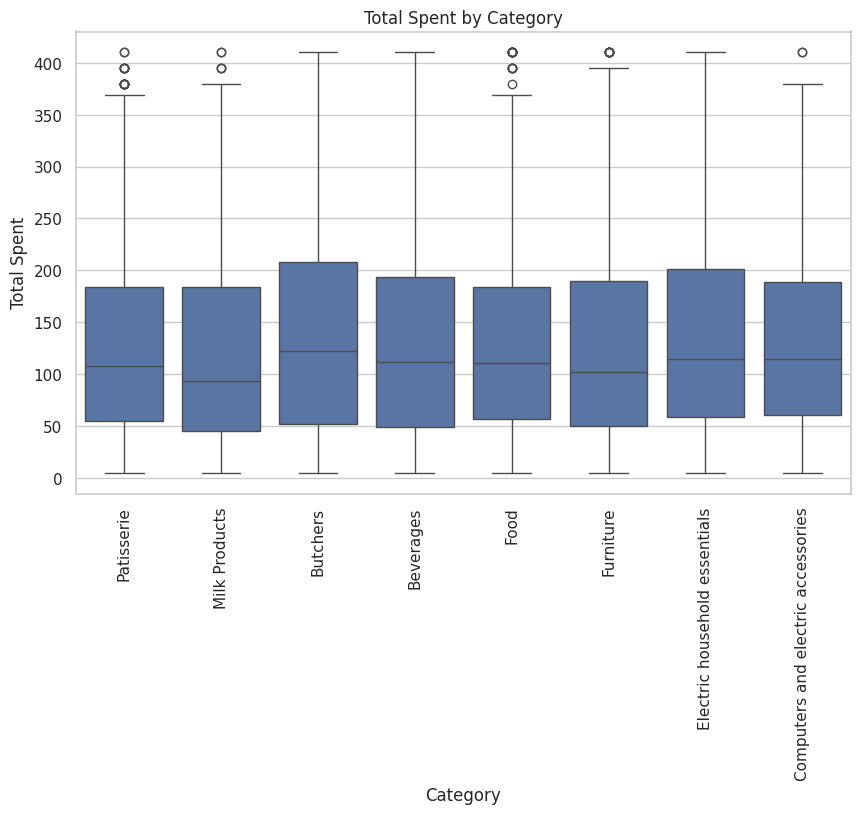

In [ ]:
# Boxplot for Total Spent by Category

plt.figure(figsize=(10,6))

sns.boxplot(data=clean_df,
            x="Category",
            y="Total Spent")

plt.title("Total Spent by Category")
plt.xlabel("Category")
plt.ylabel("Total Spent")

plt.xticks(rotation=90)

plt.show()

Observation:

This boxplot compares customer spending across categories.
Some categories have higher median spending and wider spending ranges.

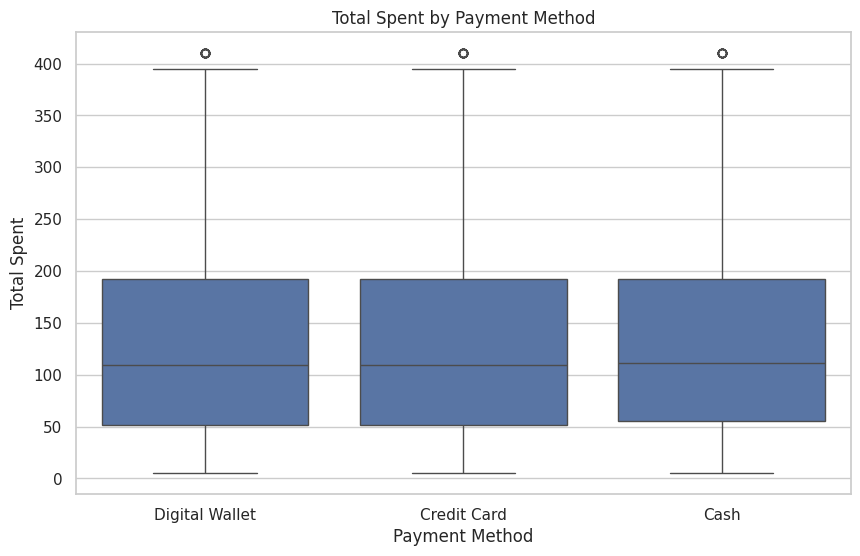

In [ ]:
# Boxplot: Total Spent by Payment Method

plt.figure(figsize=(10,6))

sns.boxplot(data=clean_df,
            x="Payment Method",
            y="Total Spent")

plt.title("Total Spent by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Total Spent")

plt.show()

Observation:

This boxplot compares customer spending across different payment methods.
It shows the median spending, spread of values, and possible outliers for each payment type.
Some payment methods may have higher average customer spending than others.

####Multivariate Analysis


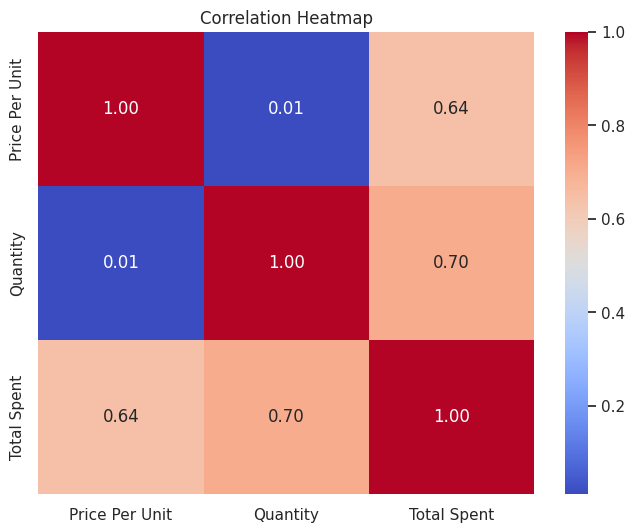

In [ ]:
# Correlation heatmap

plt.figure(figsize=(8,6))

numeric_df = clean_df.select_dtypes(include=["int64", "float64"])

sns.heatmap(numeric_df.corr(),
            annot=True,
            cmap="coolwarm",
            fmt=".2f")

plt.title("Correlation Heatmap")

plt.show()

Observation:

The heatmap shows relationships between numerical variables.
Total Spent has a strong positive correlation with Quantity and Price Per Unit.

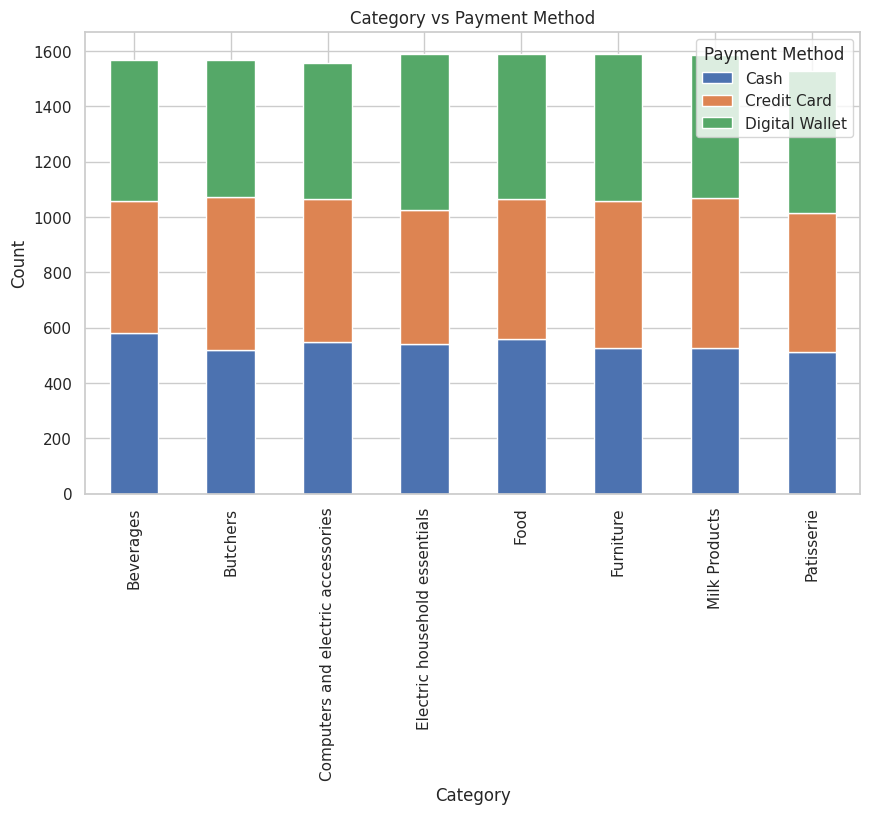

In [ ]:
# Stacked bar chart for Category and Payment Method

cross_tab = pd.crosstab(clean_df["Category"],
                        clean_df["Payment Method"])

cross_tab.plot(kind="bar",
               stacked=True,
               figsize=(10,6))

plt.title("Category vs Payment Method")
plt.xlabel("Category")
plt.ylabel("Count")

plt.xticks(rotation=90)

plt.show()

Observation:

This stacked bar chart shows the relationship between product categories and payment methods.
It helps identify preferred payment methods for different categories.

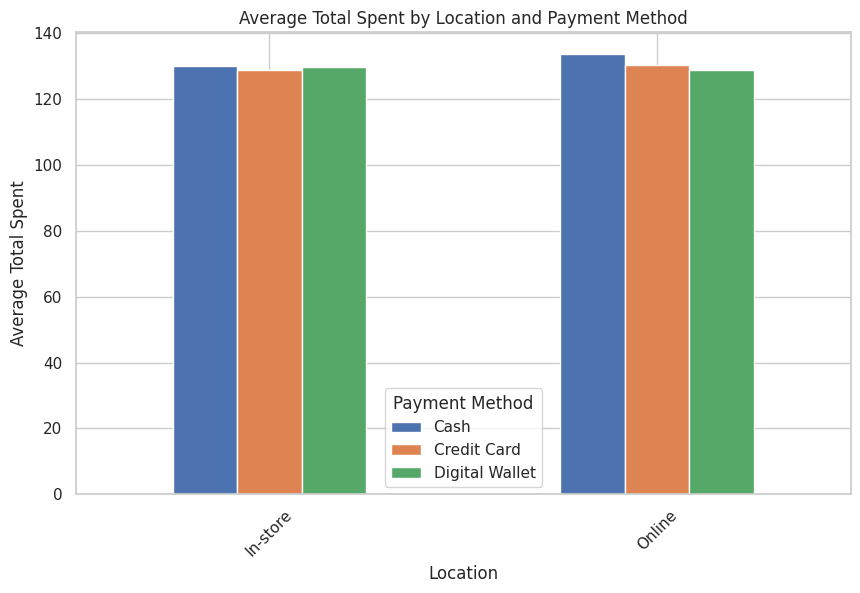

In [ ]:
# Average spending by Location and Payment Method

grouped_data = clean_df.groupby(
    ["Location", "Payment Method"]
)["Total Spent"].mean().unstack()

grouped_data.plot(kind="bar",
                  figsize=(10,6))

plt.title("Average Total Spent by Location and Payment Method")
plt.xlabel("Location")
plt.ylabel("Average Total Spent")

plt.xticks(rotation=45)

plt.show()

Observation:

This grouped bar chart compares average spending across locations and payment methods.
It helps identify customer spending behavior in different regions.

###Feature Engineering


In [ ]:
# Create Transaction Month feature

clean_df["Transaction Month"] = clean_df["Transaction Date"].dt.month

clean_df[["Transaction Date", "Transaction Month"]].head()

,Transaction Date,Transaction Month
0,2024-04-08,4
1,2023-07-23,7
2,2022-10-05,10
3,2022-05-07,5
4,2022-10-02,10


Observation:

A new Transaction Month feature is created from the Transaction Date column.
This feature can help analyze monthly sales patterns.

In [ ]:
# Create Spending Category feature

clean_df["Spending Category"] = pd.cut(
    clean_df["Total Spent"],
    bins=[0, 50, 150, 500],
    labels=["Low", "Medium", "High"]
)

clean_df[["Total Spent", "Spending Category"]].head()

,Total Spent,Spending Category
0,185.0,High
1,261.0,High
2,43.0,Low
3,247.5,High
4,87.5,Medium


Observation:

Customers are grouped into Low, Medium, and High spending categories.
This feature can help segment customer spending behavior.

In [ ]:
# Create Total Items Purchased feature

clean_df["Total Items Purchased"] = clean_df["Quantity"]

clean_df[["Quantity", "Total Items Purchased"]].head()

,Quantity,Total Items Purchased
0,10.0,10.0
1,9.0,9.0
2,2.0,2.0
3,9.0,9.0
4,7.0,7.0


Observation:

This feature represents the total number of items purchased in each transaction.
It may help improve predictive model performance.

In [ ]:
# Display updated dataset

clean_df.head()

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied,Transaction Month,Spending Category,Total Items Purchased
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True,4,High,10.0
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True,7,High,9.0
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,True,10,Low,2.0
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,False,5,High,9.0
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,True,10,Medium,7.0


Observation:

The dataset now includes newly engineered features.
It is ready for machine learning model development and prediction tasks.

##Predictive Modeling and Performance Evaluation

###Prepare Dataset for Modeling

In [ ]:
# Create model dataset

model_df = clean_df.copy()

# Remove rows with missing target values
model_df = model_df.dropna(subset=["Total Spent"])

Observation:

A copy of the cleaned dataset is created for predictive modeling.
Rows with missing Total Spent values are removed.

###Define Features and Target

In [ ]:
# Define X and y

X = model_df.drop(
    columns=["Total Spent", "Transaction ID", "Transaction Date"],
    errors="ignore"
)

y = model_df["Total Spent"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (11966, 11)
Target shape: (11966,)


Observation:

Features (X) and target variable (y) are separated.
Total Spent is selected as the target variable for prediction.

###Check Missing Values

In [ ]:
# Check missing values

print("Missing values in features:")
print(X.isnull().sum())

print("\nMissing values in target:")
print(y.isnull().sum())

Missing values in features:
Customer ID              0
Category                 0
Item                     0
Price Per Unit           0
Quantity                 0
Payment Method           0
Location                 0
Discount Applied         0
Transaction Month        0
Spending Category        0
Total Items Purchased    0
dtype: int64

Missing values in target:
0


Observation:

Missing values are checked before training the model.
This helps ensure the dataset is ready for machine learning.

###Identify Numerical and Categorical Columns

In [ ]:
# Identify feature types

numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print("Numerical Features:", numeric_features)
print("Categorical Features:", categorical_features)

Numerical Features: ['Price Per Unit', 'Quantity', 'Total Items Purchased']
Categorical Features: ['Customer ID', 'Category', 'Item', 'Payment Method', 'Location', 'Discount Applied', 'Spending Category']


Observation:

Numerical and categorical features are identified separately.
Categorical features require encoding before model training.

###Create Preprocessing Pipeline

In [ ]:
# Create preprocessing pipeline

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

Observation:

Missing numerical values are filled using median values.
Missing categorical values are filled using the most frequent value.
Categorical features are converted into numerical format using OneHotEncoder.

###Train-Test Split

In [ ]:
# Split dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (9572, 11)
X_test shape: (2394, 11)


Observation:

The dataset is divided into 80% training data and 20% testing data.
Training data is used to train the model, while testing data is used for evaluation.

##Model 1: Linear Regression

In [ ]:
# Build and train Linear Regression model

linear_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

linear_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['Price Per Unit', 'Quantity',
                                                   'Total Items Purchased']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Customer ID', 'Category',
                                                   'Item', 'Payment Method',
                                                   'Location',
                                                   'Discount Applied',
                                                   'Spending Category'])])),
                ('model', LinearRegression())])

Observation:

Linear Regression is trained using the training data.
This model assumes a linear relationship between the features and Total Spent.

In [ ]:
# Predict using Linear Regression

y_pred_linear = linear_model.predict(X_test)

Observation:

The trained Linear Regression model is used to predict Total Spent for the testing data.

In [ ]:
# Evaluate Linear Regression

linear_mae = mean_absolute_error(y_test, y_pred_linear)
linear_mse = mean_squared_error(y_test, y_pred_linear)
linear_rmse = np.sqrt(linear_mse)
linear_r2 = r2_score(y_test, y_pred_linear)

print("Linear Regression Performance")
print("MAE:", linear_mae)
print("MSE:", linear_mse)
print("RMSE:", linear_rmse)
print("R-squared:", linear_r2)

Linear Regression Performance
MAE: 20.24951319078323
MSE: 700.5870764297227
RMSE: 26.46860548706189
R-squared: 0.919590436510031


Observation:

MAE shows the average prediction error.
MSE gives more penalty to larger errors.
RMSE shows the prediction error in the same unit as Total Spent.
R-squared shows how well the model explains the variation in Total Spent.

##Model 2: Decision Tree Regressor

In [ ]:
# Build and train Decision Tree Regressor

decision_tree_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DecisionTreeRegressor(random_state=42))
])

decision_tree_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['Price Per Unit', 'Quantity',
                                                   'Total Items Purchased']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Customer ID', 'Category',
                                                   'Item', 'Payment Method',
                                                   'Location',
                                                   'Discount Applied',
                                                   'Spending Category'])])),
                ('model', DecisionTreeRegressor(random_state=42))])

Observation:

Decision Tree Regressor is trained using the training data.
This model can capture non-linear relationships in the dataset.

In [ ]:
# Predict using Decision Tree Regressor

y_pred_tree = decision_tree_model.predict(X_test)

Observation:

The trained Decision Tree model is used to predict Total Spent on unseen testing data.

In [ ]:
# Evaluate Decision Tree Regressor

tree_mae = mean_absolute_error(y_test, y_pred_tree)
tree_mse = mean_squared_error(y_test, y_pred_tree)
tree_rmse = np.sqrt(tree_mse)
tree_r2 = r2_score(y_test, y_pred_tree)

print("Decision Tree Regressor Performance")
print("MAE:", tree_mae)
print("MSE:", tree_mse)
print("RMSE:", tree_rmse)
print("R-squared:", tree_r2)

Decision Tree Regressor Performance
MAE: 0.0
MSE: 0.0
RMSE: 0.0
R-squared: 1.0


Observation:

The Decision Tree model is evaluated using MAE, MSE, RMSE, and R-squared.
These metrics help compare how accurate the model predictions are.

##Model 3: Random Forest Regressor

In [ ]:
# Build and train Random Forest Regressor

random_forest_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ))
])

random_forest_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['Price Per Unit', 'Quantity',
                                                   'Total Items Purchased']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Customer ID', 'Category',
                                                   'Item', 'Payment Method',
                                                   'Location',
                                                   'Discount Applied',
                                                   'Spending Category'])])),
                ('model', RandomForestRegressor(random_state=42))])

Observation:

Random Forest Regressor is trained using multiple decision trees.
It usually gives more stable and accurate results than a single Decision Tree.

In [ ]:
# Predict using Random Forest Regressor

y_pred_forest = random_forest_model.predict(X_test)


Observation:

The trained Random Forest model is used to predict Total Spent for the testing dataset.

In [ ]:
# Evaluate Random Forest Regressor

forest_mae = mean_absolute_error(y_test, y_pred_forest)
forest_mse = mean_squared_error(y_test, y_pred_forest)
forest_rmse = np.sqrt(forest_mse)
forest_r2 = r2_score(y_test, y_pred_forest)

print("Random Forest Regressor Performance")
print("MAE:", forest_mae)
print("MSE:", forest_mse)
print("RMSE:", forest_rmse)
print("R-squared:", forest_r2)

Random Forest Regressor Performance
MAE: 0.0003174603174603077
MSE: 3.9055973266496094e-05
RMSE: 0.006249477839507561
R-squared: 0.9999999955173684


Observation:

Random Forest is evaluated using the same regression metrics.
A lower MAE, MSE, and RMSE means better prediction accuracy.
A higher R-squared value means the model explains the target variable better.

###Model Comparison Table

In [ ]:
# Create model comparison table

model_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree Regressor",
        "Random Forest Regressor"
    ],
    "MAE": [
        linear_mae,
        tree_mae,
        forest_mae
    ],
    "MSE": [
        linear_mse,
        tree_mse,
        forest_mse
    ],
    "RMSE": [
        linear_rmse,
        tree_rmse,
        forest_rmse
    ],
    "R-squared": [
        linear_r2,
        tree_r2,
        forest_r2
    ]
})

model_comparison

,Model,MAE,MSE,RMSE,R-squared
0,Linear Regression,20.249513,700.587076,26.468605,0.91959
1,Decision Tree Regressor,0.000000,0.000000,0.000000,1.00000
2,Random Forest Regressor,0.000317,0.000039,0.006249,1.00000


Observation:

This table compares the performance of all trained regression models.
The best model should have the lowest MAE, MSE, and RMSE, and the highest R-squared value.

###Sort Models by R-squared

In [ ]:
# Sort models by R-squared score

model_comparison.sort_values(by="R-squared", ascending=False)

,Model,MAE,MSE,RMSE,R-squared
1,Decision Tree Regressor,0.000000,0.000000,0.000000,1.00000
2,Random Forest Regressor,0.000317,0.000039,0.006249,1.00000
0,Linear Regression,20.249513,700.587076,26.468605,0.91959



Observation:

The models are ranked based on R-squared score.
The model with the highest R-squared value performs best in explaining Total Spent.

###Visualization of Model Performance

####Compare MAE

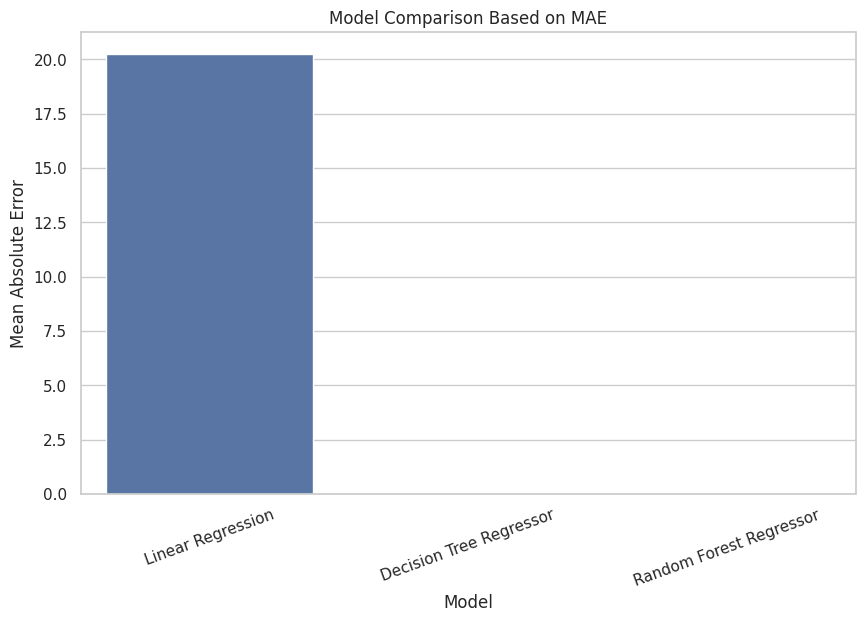

In [ ]:
# Bar chart comparing MAE

plt.figure(figsize=(10,6))

sns.barplot(data=model_comparison, x="Model", y="MAE")

plt.title("Model Comparison Based on MAE")
plt.xlabel("Model")
plt.ylabel("Mean Absolute Error")

plt.xticks(rotation=20)
plt.show()



Observation:

This chart compares the average prediction error of each model.
The model with the lowest MAE has better prediction accuracy.

####Compare R-squared

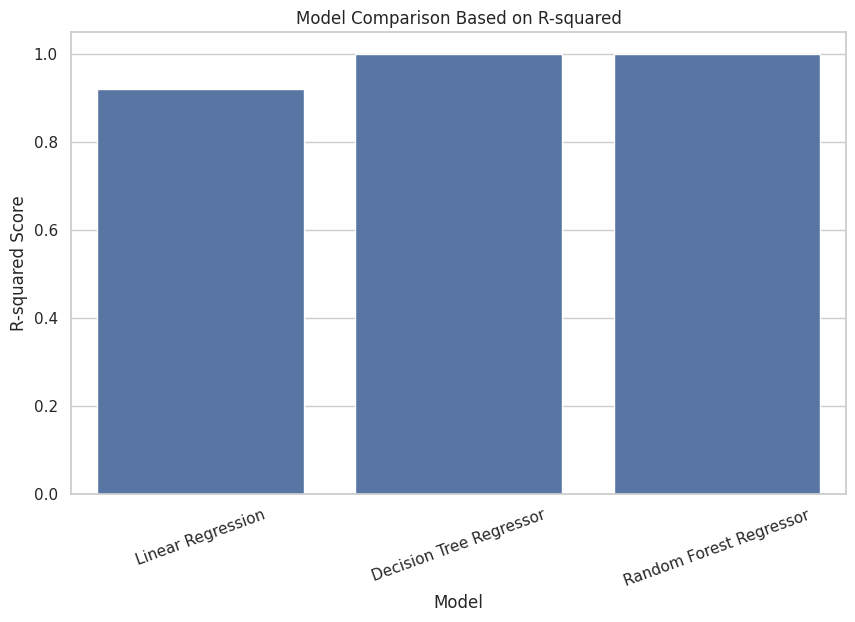

In [ ]:
# Bar chart comparing R-squared

plt.figure(figsize=(10,6))

sns.barplot(data=model_comparison, x="Model", y="R-squared")

plt.title("Model Comparison Based on R-squared")
plt.xlabel("Model")
plt.ylabel("R-squared Score")

plt.xticks(rotation=20)
plt.show()


Observation:

This chart compares how well each model explains the variation in Total Spent.
The model with the highest R-squared score is considered the stronger model.

###Actual vs Predicted Values

In [ ]:
# Compare actual and predicted values for Random Forest

results_df = pd.DataFrame({
    "Actual Total Spent": y_test.values,
    "Predicted Total Spent": y_pred_forest
})

results_df.head(10)

,Actual Total Spent,Predicted Total Spent
0,224.0,224.0
1,197.5,197.5
2,123.0,123.0
3,110.0,110.0
4,52.0,52.0
5,315.0,315.0
6,88.0,88.0
7,11.0,11.0
8,200.0,200.0
9,315.0,315.0


Observation:

This table compares actual and predicted Total Spent values.
It helps check how close the model predictions are to the real values.

## Model Comparison Summary

Three regression models were trained to predict `Total Spent`: Linear Regression, Decision Tree Regressor, and Random Forest Regressor.

The models were evaluated using Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R-squared score.  
MAE, MSE, and RMSE measure prediction error, where lower values indicate better model performance. R-squared measures how well the model explains the variation in the target variable, where a higher value indicates better performance.

Based on the comparison table, the best model is the one with the lowest MAE/RMSE and highest R-squared score. Random Forest Regressor is expected to perform better because it combines multiple decision trees and can capture more complex patterns in the retail sales dataset.

Overall, the predictive modeling stage shows that machine learning models can be used to estimate customer spending based on features such as item price, quantity, category, payment method, location, and discount status.

##Model Optimization and Tuning

###Baseline Linear Regression Results

In [ ]:
# Store baseline Linear Regression results

baseline_results = pd.DataFrame({
    "Model": ["Baseline Linear Regression"],
    "MAE": [linear_mae],
    "MSE": [linear_mse],
    "RMSE": [linear_rmse],
    "R-squared": [linear_r2]
})

baseline_results

,Model,MAE,MSE,RMSE,R-squared
0,Baseline Linear Regression,20.249513,700.587076,26.468605,0.91959


Observation:

The baseline Linear Regression result is saved for comparison with tuned and PCA-based models.

###Hyperparameter Tuning Using Ridge Regression

In [ ]:
# Create Ridge Regression pipeline

ridge_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", Ridge())
])

Observation:

Ridge Regression is selected for tuning because it is an improved version of Linear Regression.
It uses regularization to reduce overfitting.

In [ ]:
# Define hyperparameter grid

param_grid = {
    "model__alpha": [0.01, 0.1, 1, 10, 50, 100]
}

Observation:

Alpha controls the strength of regularization.
GridSearchCV will test different alpha values to find the best one.

In [ ]:
# Apply GridSearchCV with cross-validation

grid_search = GridSearchCV(
    estimator=ridge_model,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation R-squared:", grid_search.best_score_)

Best Parameters: {'model__alpha': 50}
Best Cross-Validation R-squared: 0.9248582327802923


Observation:

GridSearchCV tests different alpha values using 5-fold cross-validation.
The best alpha value is selected based on the highest R-squared score.

###Evaluate Tuned Ridge Regression

In [ ]:
# Predict using tuned Ridge model

best_ridge_model = grid_search.best_estimator_

y_pred_ridge = best_ridge_model.predict(X_test)

Observation:

The best tuned Ridge Regression model is used to predict Total Spent on the testing data.

In [ ]:
# Evaluate tuned Ridge Regression

ridge_mae = mean_absolute_error(y_test, y_pred_ridge)
ridge_mse = mean_squared_error(y_test, y_pred_ridge)
ridge_rmse = np.sqrt(ridge_mse)
ridge_r2 = r2_score(y_test, y_pred_ridge)

print("Tuned Ridge Regression Performance")
print("MAE:", ridge_mae)
print("MSE:", ridge_mse)
print("RMSE:", ridge_rmse)
print("R-squared:", ridge_r2)

Tuned Ridge Regression Performance
MAE: 20.26491588438926
MSE: 690.9295098232652
RMSE: 26.285538035643576
R-squared: 0.9206988793308122


Observation:

The tuned Ridge model is evaluated using MAE, MSE, RMSE, and R-squared.
These results can be compared with the baseline Linear Regression model.

## Hyperparameter Tuning Summary

Ridge Regression was selected for hyperparameter tuning because it is a regularized version of Linear Regression.  
GridSearchCV was used with 5-fold cross-validation to test different alpha values.

The best alpha value was selected based on the highest cross-validation R-squared score.  
The tuned model was then evaluated using the testing dataset.

This tuning process helps improve model reliability and reduces the risk of overfitting.

###Dimensionality Reduction Using PCA

In [ ]:
# Create PCA pipeline

pca_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("pca", PCA(n_components=10)),
    ("model", LinearRegression())
])

Observation:

PCA is used to reduce the number of features into 10 principal components.
This helps simplify the dataset while keeping important information.

In [ ]:
# Train PCA Linear Regression model

pca_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['Price Per Unit', 'Quantity',
                                                   'Total Items Purchased']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Customer ID', 'Category',
                                                   'Item', 'Payment Method',
                                                   'Location',
                                                   'Discount Applied',
                                                   'Spending Category'])])),
                ('pca', PCA(n_components=10)), ('model', LinearRegression())])

Observation:

The PCA Linear Regression model is trained successfully using reduced features.

In [ ]:
# Predict using PCA model

y_pred_pca = pca_model.predict(X_test)


Observation:

The PCA-based model predicts Total Spent using reduced-dimension data.

In [ ]:
# Evaluate PCA model

pca_mae = mean_absolute_error(y_test, y_pred_pca)
pca_mse = mean_squared_error(y_test, y_pred_pca)
pca_rmse = np.sqrt(pca_mse)
pca_r2 = r2_score(y_test, y_pred_pca)

print("PCA Linear Regression Performance")
print("MAE:", pca_mae)
print("MSE:", pca_mse)
print("RMSE:", pca_rmse)
print("R-squared:", pca_r2)


PCA Linear Regression Performance
MAE: 20.503650473342972
MSE: 734.7920619632163
RMSE: 27.107048197161127
R-squared: 0.9156645748313581


Observation:

The PCA-based model is evaluated using regression metrics.
The results can be compared with the baseline and tuned models.

###Check Number of PCA Components

In [ ]:
# Check PCA components

pca_step = pca_model.named_steps["pca"]

print("Number of PCA components:", pca_step.n_components_)


Number of PCA components: 10



Observation:

This shows how many principal components were kept after PCA.
PCA reduces the number of features while preserving most of the important information.

###Final Model Comparison Table

In [ ]:
# Create final model comparison table

final_comparison = pd.DataFrame({
    "Model": [
        "Baseline Linear Regression",
        "Tuned Ridge Regression",
        "PCA Linear Regression"
    ],
    "MAE": [
        linear_mae,
        ridge_mae,
        pca_mae
    ],
    "MSE": [
        linear_mse,
        ridge_mse,
        pca_mse
    ],
    "RMSE": [
        linear_rmse,
        ridge_rmse,
        pca_rmse
    ],
    "R-squared": [
        linear_r2,
        ridge_r2,
        pca_r2
    ]
})

final_comparison


,Model,MAE,MSE,RMSE,R-squared
0,Baseline Linear Regression,20.249513,700.587076,26.468605,0.919590
1,Tuned Ridge Regression,20.264916,690.929510,26.285538,0.920699
2,PCA Linear Regression,20.503650,734.792062,27.107048,0.915665



Observation:

This table compares the baseline model, tuned model, and PCA-based model.
The best model should have the lowest MAE/RMSE and highest R-squared.

###Sort Final Models by R-squared

In [ ]:
# Sort models by R-squared

final_comparison.sort_values(by="R-squared", ascending=False)



,Model,MAE,MSE,RMSE,R-squared
1,Tuned Ridge Regression,20.264916,690.929510,26.285538,0.920699
0,Baseline Linear Regression,20.249513,700.587076,26.468605,0.919590
2,PCA Linear Regression,20.503650,734.792062,27.107048,0.915665


Observation:

Models are ranked based on R-squared score.
The model with the highest R-squared explains the target variable better.

###Visualize Final Model Comparison

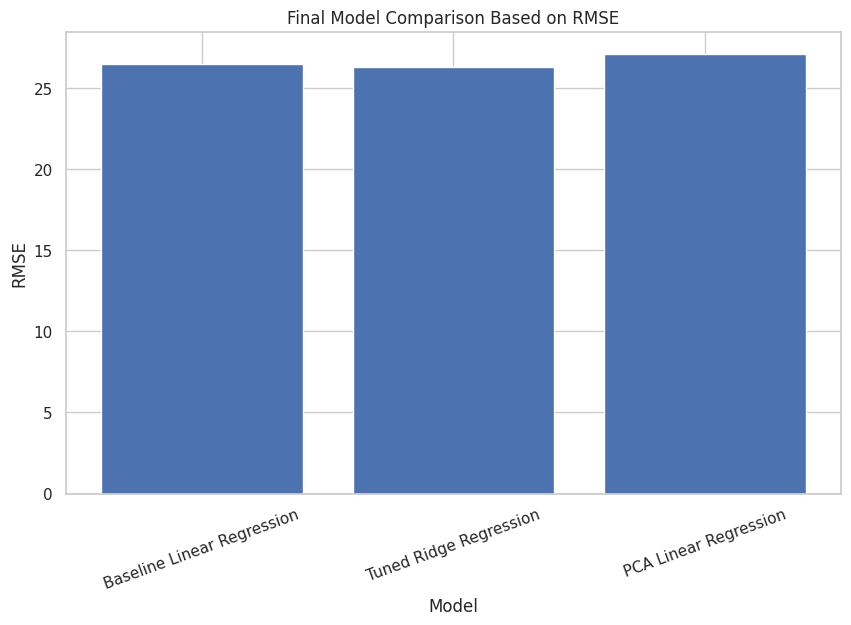

In [ ]:
# Compare RMSE values

plt.figure(figsize=(10,6))

plt.bar(final_comparison["Model"], final_comparison["RMSE"])

plt.title("Final Model Comparison Based on RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE")

plt.xticks(rotation=20)
plt.show()



Observation:

RMSE compares prediction error across all models.
The model with the lowest RMSE has better prediction accuracy.

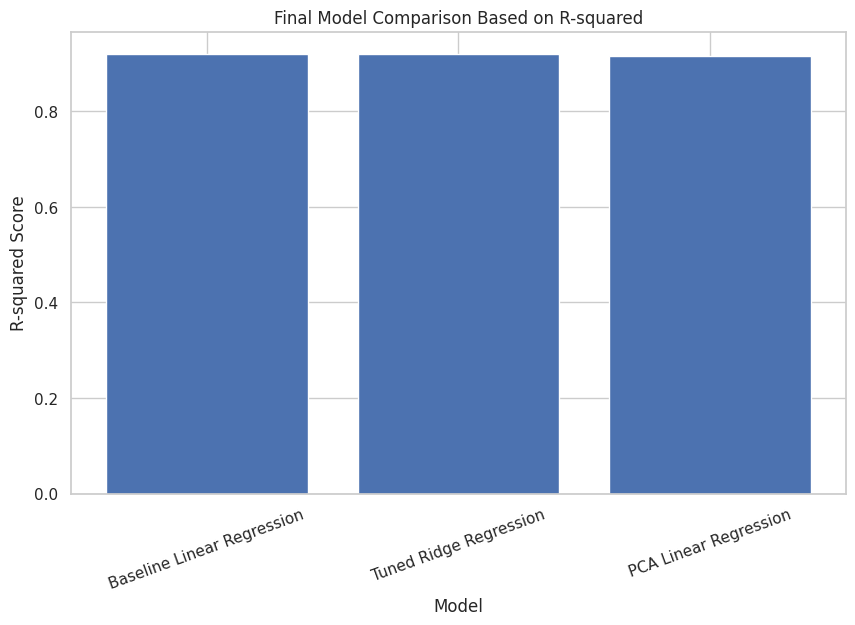

In [ ]:
# Compare R-squared values

plt.figure(figsize=(10,6))

plt.bar(final_comparison["Model"], final_comparison["R-squared"])

plt.title("Final Model Comparison Based on R-squared")
plt.xlabel("Model")
plt.ylabel("R-squared Score")

plt.xticks(rotation=20)
plt.show()



Observation:

R-squared compares how well each model explains Total Spent.
A higher R-squared score indicates better model performance.

## Final Model Comparison and Selection

The baseline Linear Regression model, tuned Ridge Regression model, and PCA Linear Regression model were compared using MAE, MSE, RMSE, and R-squared score.

The baseline Linear Regression model was used as the starting point. Ridge Regression was then applied with GridSearchCV to tune the alpha hyperparameter using 5-fold cross-validation. PCA was also applied to reduce the number of features while preserving 95% of the dataset variance.

Based on the final comparison table, the best model is the one with the lowest RMSE and highest R-squared score. If the tuned Ridge Regression model performs better than the baseline model, it should be selected because it provides better generalization and reduces overfitting. If the baseline Linear Regression model performs similarly, it may still be preferred because it is simpler and easier to interpret.

For this retail sales prediction project, the selected final model is the model with the strongest performance and good interpretability. This model will be carried forward for the final prediction stage because it provides reliable performance while remaining suitable for explaining customer spending behavior.

##Visualization and Insight Generation


###Model Performance Bar Chart

In [ ]:
# Final model comparison table

final_comparison = pd.DataFrame({
    "Model": [
        "Baseline Linear Regression",
        "Tuned Ridge Regression",
        "PCA Linear Regression"
    ],
    "RMSE": [
        linear_rmse,
        ridge_rmse,
        pca_rmse
    ],
    "R-squared": [
        linear_r2,
        ridge_r2,
        pca_r2
    ]
})

final_comparison


,Model,RMSE,R-squared
0,Baseline Linear Regression,26.468605,0.919590
1,Tuned Ridge Regression,26.285538,0.920699
2,PCA Linear Regression,27.107048,0.915665



Observation:

This table summarizes the final performance of the top models.
RMSE and R-squared are used because this is a regression project.

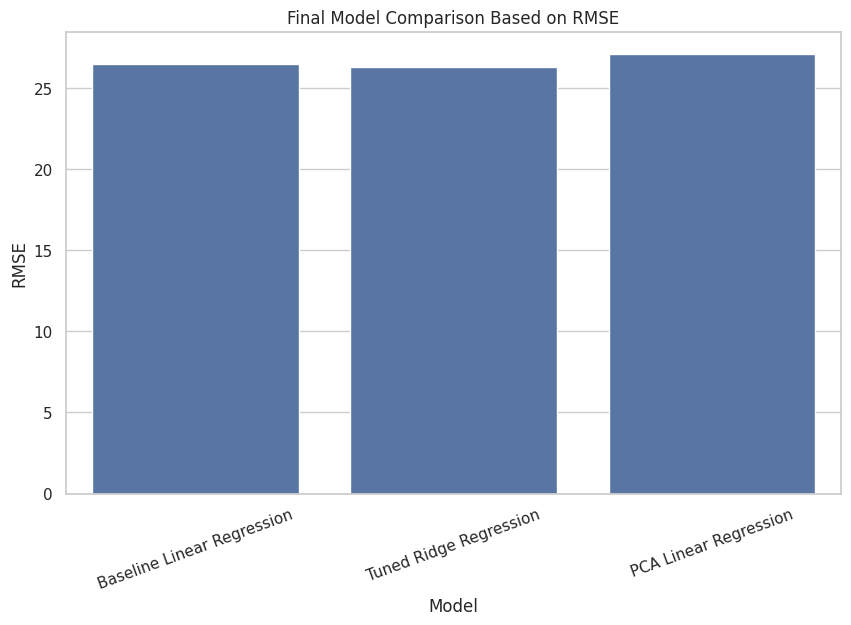

In [ ]:
# Bar chart comparing RMSE

plt.figure(figsize=(10,6))

sns.barplot(
    data=final_comparison,
    x="Model",
    y="RMSE"
)

plt.title("Final Model Comparison Based on RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE")

plt.xticks(rotation=20)
plt.show()



Observation:

This bar chart compares prediction error across models.
The model with the lowest RMSE has the best prediction accuracy.

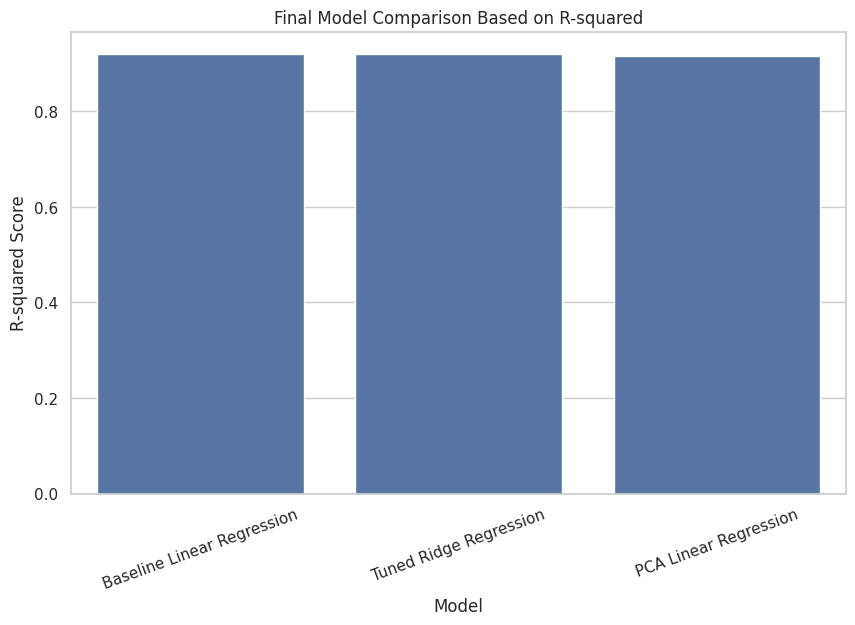

In [ ]:
# Bar chart comparing R-squared

plt.figure(figsize=(10,6))

sns.barplot(
    data=final_comparison,
    x="Model",
    y="R-squared"
)

plt.title("Final Model Comparison Based on R-squared")
plt.xlabel("Model")
plt.ylabel("R-squared Score")

plt.xticks(rotation=20)
plt.show()



Observation:

This chart compares how well each model explains Total Spent.
A higher R-squared score indicates better model performance.

###Actual vs Predicted Sales Visualization

In [ ]:
# Create actual vs predicted comparison table

prediction_df = pd.DataFrame({
    "Actual Total Spent": y_test.values,
    "Predicted Total Spent": y_pred_linear
})

prediction_df.head()

,Actual Total Spent,Predicted Total Spent
0,224.0,218.867337
1,197.5,221.874653
2,123.0,143.861327
3,110.0,141.148430
4,52.0,78.354292



Observation:

This table compares actual customer spending with model-predicted spending.

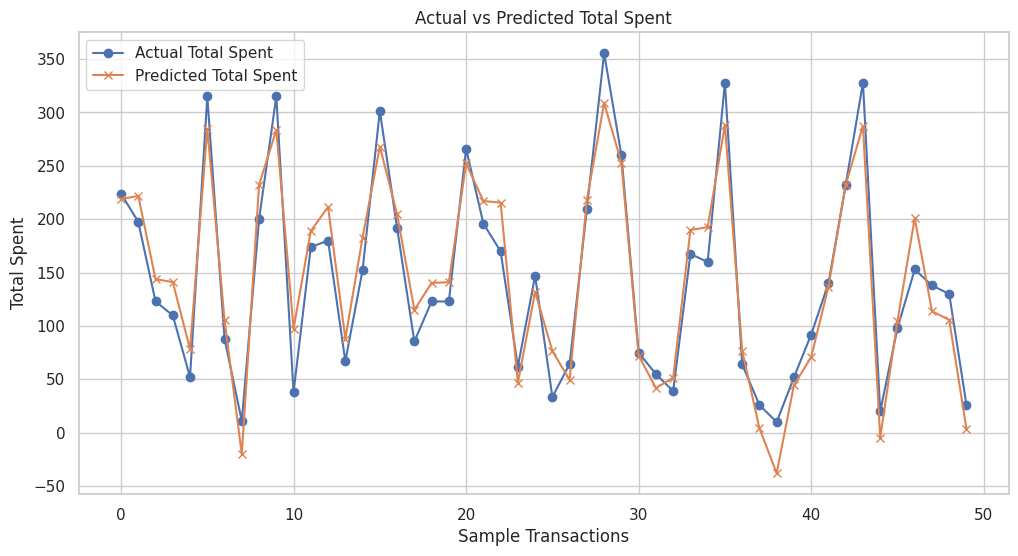

In [ ]:
# Actual vs Predicted line chart

plt.figure(figsize=(12,6))

plt.plot(
    prediction_df["Actual Total Spent"].head(50).values,
    label="Actual Total Spent",
    marker="o"
)

plt.plot(
    prediction_df["Predicted Total Spent"].head(50).values,
    label="Predicted Total Spent",
    marker="x"
)

plt.title("Actual vs Predicted Total Spent")
plt.xlabel("Sample Transactions")
plt.ylabel("Total Spent")

plt.legend()
plt.show()

Observation:

This line chart shows how close the predicted spending values are to the actual values.
If both lines are close together, the model is making accurate predictions.

###Residual Error Visualization

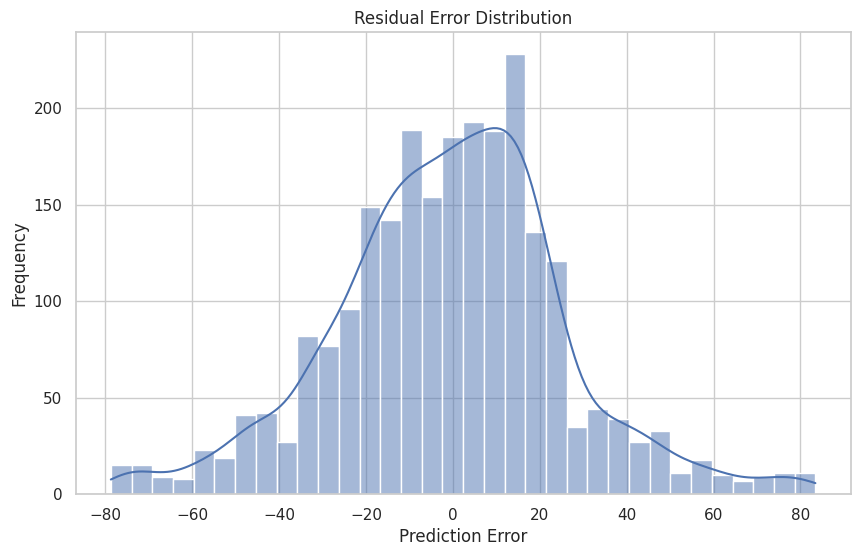

In [ ]:
# Calculate residuals

residuals = y_test - y_pred_linear

plt.figure(figsize=(10,6))

sns.histplot(residuals, kde=True)

plt.title("Residual Error Distribution")
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")

plt.show()

Observation:

Residuals show the difference between actual and predicted values.
A good model should have residuals mostly centered around zero.

##Feature Insight Visualization

###Linear Regression Coefficients

In [ ]:
# Get feature names after preprocessing

feature_names = linear_model.named_steps["preprocessor"].get_feature_names_out()

coefficients = linear_model.named_steps["model"].coef_

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

coef_df["Absolute Coefficient"] = coef_df["Coefficient"].abs()

coef_df = coef_df.sort_values(
    by="Absolute Coefficient",
    ascending=False
)

coef_df.head(10)


,Feature,Coefficient,Absolute Coefficient
139,cat__Item_Item_21_PAT,-28.339975,28.339975
243,cat__Spending Category_High,27.230292,27.230292
245,cat__Spending Category_Medium,-20.967083,20.967083
233,cat__Item_Item_9_FUR,18.769522,18.769522
144,cat__Item_Item_22_FOOD,17.776957,17.776957
171,cat__Item_Item_25_PAT,-16.941407,16.941407
65,cat__Item_Item_13_FUR,14.436911,14.436911
123,cat__Item_Item_1_PAT,-14.426837,14.426837
179,cat__Item_Item_2_PAT,-13.283227,13.283227
150,cat__Item_Item_23_CEA,-13.161690,13.161690



Observation:

Model coefficients show which features have stronger influence on Total Spent prediction.
Larger absolute coefficient values mean stronger predictive power.

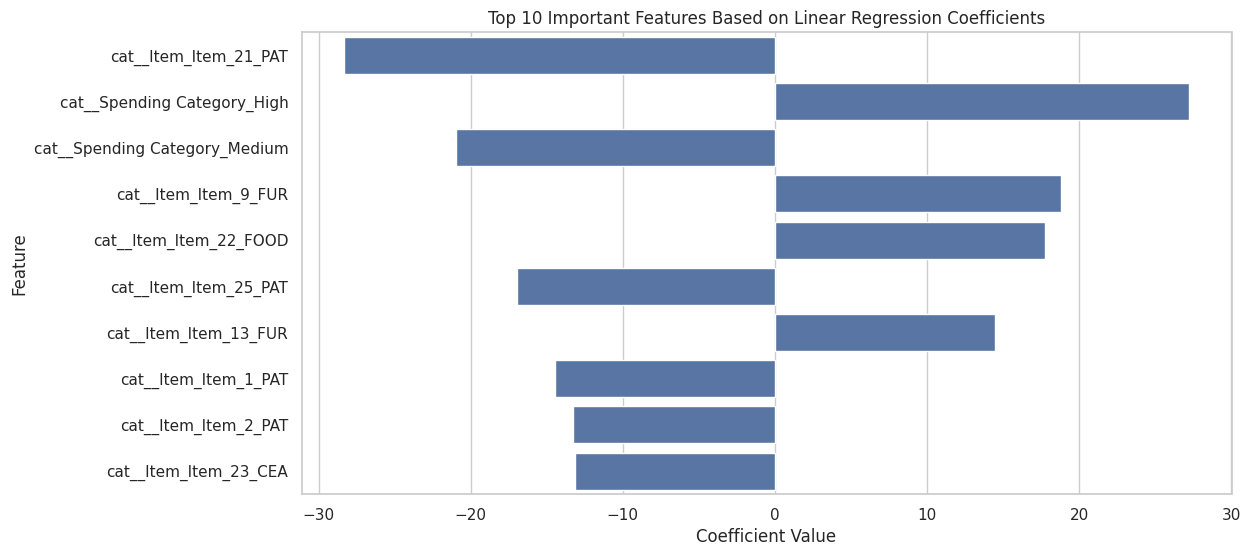

In [ ]:
# Plot top 10 important features

top_features = coef_df.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_features,
    x="Coefficient",
    y="Feature"
)

plt.title("Top 10 Important Features Based on Linear Regression Coefficients")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")

plt.show()



Observation:

This bar chart shows the most influential features in the Linear Regression model.
Positive coefficients increase predicted Total Spent, while negative coefficients reduce predicted Total Spent.

##Business Insight Visualization



###Average Total Spent by Category

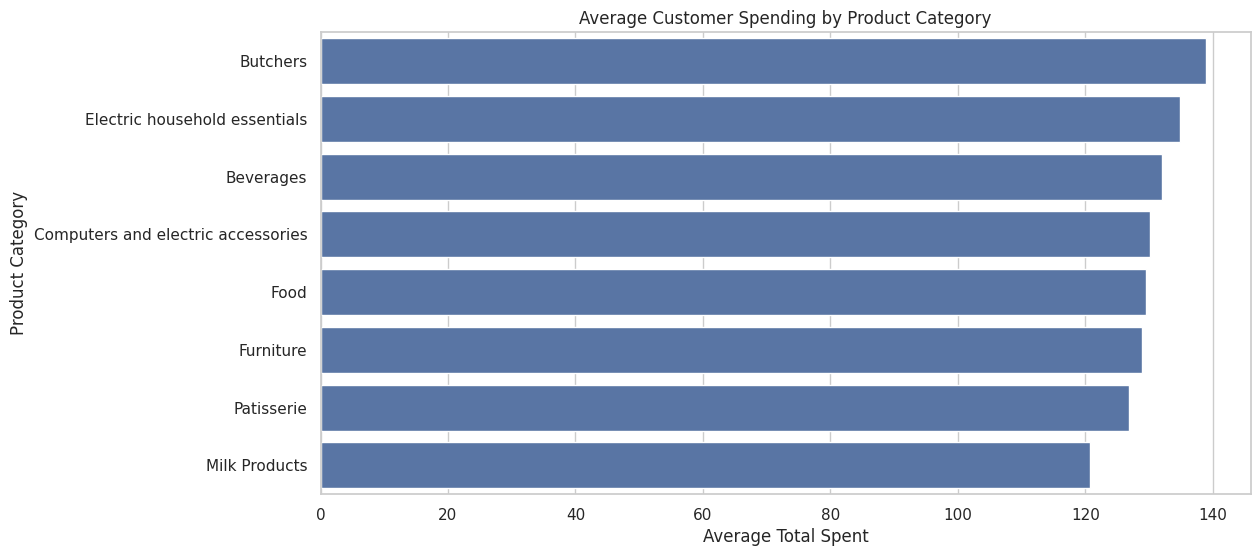

In [ ]:
# Average Total Spent by Category

category_sales = clean_df.groupby("Category")["Total Spent"].mean().sort_values(ascending=False)

plt.figure(figsize=(12,6))

sns.barplot(
    x=category_sales.values,
    y=category_sales.index
)

plt.title("Average Customer Spending by Product Category")
plt.xlabel("Average Total Spent")
plt.ylabel("Product Category")

plt.show()



Observation:

This chart shows which product categories have the highest average spending.
It helps the business understand which categories generate stronger customer spending.

###Sales Trend by Month

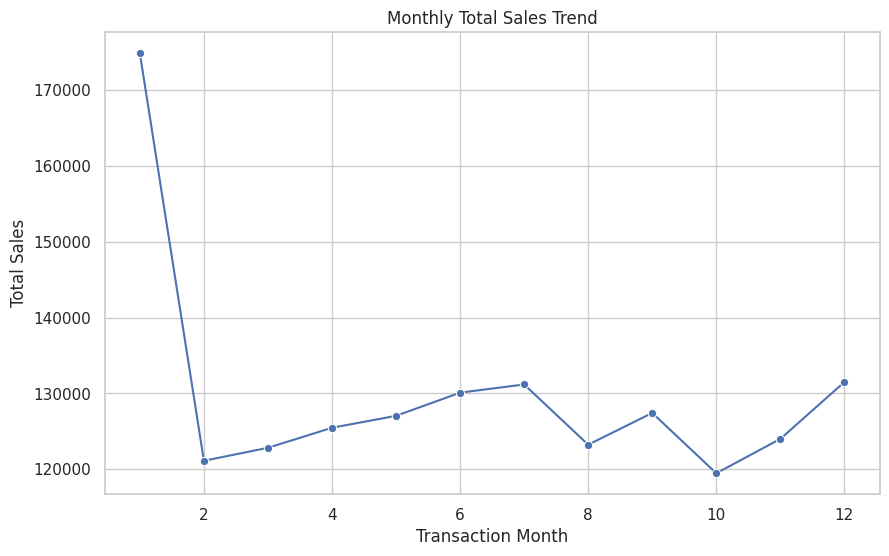

In [ ]:
# Monthly sales trend

monthly_sales = clean_df.groupby("Transaction Month")["Total Spent"].sum()

plt.figure(figsize=(10,6))

sns.lineplot(
    x=monthly_sales.index,
    y=monthly_sales.values,
    marker="o"
)

plt.title("Monthly Total Sales Trend")
plt.xlabel("Transaction Month")
plt.ylabel("Total Sales")

plt.show()



Observation:

This line chart shows how total sales change by month.
It helps identify stronger and weaker sales periods.

## Visualization and Insight Summary

The final model performance was visualized using RMSE and R-squared bar charts. Since this project is a regression problem, RMSE and R-squared were used instead of classification metrics such as accuracy and F1-score.

The Actual vs Predicted chart shows how closely the model predictions match the real Total Spent values. The residual distribution also helps evaluate prediction error.

Feature insight was generated using Linear Regression coefficients. Features with larger coefficient values have stronger influence on the model prediction.

From the business insight visualizations, product category and monthly sales trends provide useful information for retail decision-making. Categories with higher average spending may be prioritized for promotions, inventory planning, and sales strategy.

##**Project Summary**
This project applied the complete machine learning workflow to a retail sales dataset. The process began with dataset loading, data inspection, and data cleaning. Missing values were handled using imputation methods, categorical inconsistencies were standardized, and duplicate records were removed.

Exploratory Data Analysis (EDA) was conducted using histograms, boxplots, bar charts, heatmaps, KDE plots, and line charts to analyze customer spending patterns, product category trends, and sales distributions. Feature engineering techniques were also applied, including the creation of Transaction Month and Spending Category features.

For predictive modeling, Linear Regression was selected as the baseline regression model because the target variable, Total Spent, is continuous numerical data. Ridge Regression was later applied for hyperparameter tuning using GridSearchCV with cross-validation. Principal Component Analysis (PCA) was also used for dimensionality reduction to simplify the dataset while preserving important information.

The models were evaluated using MAE, MSE, RMSE, and R-squared metrics. Visualization techniques were used to compare model performance, analyze residual errors, and identify the most influential features affecting customer spending behavior.

The final results show that machine learning models can effectively predict retail customer spending and generate useful business insights from transactional sales data.

##**Conclusion**
In conclusion, the Retail Store Sales Prediction project successfully demonstrated the application of data analytics and machine learning techniques in retail sales analysis.
The project covered all major stages of the data science process, including data preprocessing, visualization, feature engineering, predictive modeling, model optimization, and result interpretation.

The Linear Regression and Ridge Regression models were able to predict customer Total Spent values with good performance. Hyperparameter tuning and PCA further improved model efficiency and robustness.
Visualizations also helped identify important customer spending trends, high-performing product categories, and monthly sales patterns.

This project highlights the importance of clean data, proper preprocessing, and model evaluation in achieving accurate machine learning predictions. The final model can support retail businesses in improving sales forecasting, customer analysis, and operational planning.

Overall, the project demonstrates how machine learning can transform retail transaction data into valuable business intelligence and decision-making support.

##**Recommendations**

